# Sync behavioral and imaging data

Todo:
* Load in behav data (uvr expt)
* load in img data (pickle file)
* create df with the florescence data (each col is a roi) from pickle file DF_G
* modify findimgframetimes to use fpv from pickle
* then run combinImagingAndPosDf to sync data

## Imports

In [6]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from gulp2p import utils as utils
from gulp2p import ImagingPreProc as iPP
from gulp2p import ROIs as ROIs

## Select data

In [7]:
img_pickle = Path(utils.loadFileNames(single_file=True, title="Select preprocessed imaging data"))
behavior_data = Path(utils.loadFileNames(single_file=True, title="Select behavioral data"))

## Load data

### Load behavioral data

In [8]:
# uvr.psDf starts with columns: frame, time, dt, x, y, angle, dx, dy, dxattempt, dyattempt
uvr = lp.constructUnityVRexperiment(str(behavior_data.parent), behavior_data.name)

correcting for Unity angle convention.


In [9]:
uvr.metadata

{'expid': 'testExp',
 'experiment': 'test experiment',
 'genotype': 'testGenotype',
 'sex': 'NA',
 'flyid': 'NA',
 'trial': 'trial6-44-42',
 'date': '2023-10-16',
 'time': '16-44-42',
 'ballRad': 0.04699999839067459,
 'setFrameRate': 60,
 'notes': 'NA',
 'angle_convention': 'right-handed'}

In [10]:
posAnalysis.computeVelocities(uvr.posDf) # Adds columns: vT, vR, vT_filt, vR_filt
posAnalysis.position(uvr, derive=True) # Adds columns: ds, s, dTh, radangle
uvr.posDf.head()

,frame,time,dt,x,y,angle,dx,dy,dxattempt,dyattempt,vT,vR,vT_filt,vR_filt,ds,s,dTh,radangle
0,1.0,0.000000,0.020000,-0.000309,-0.000676,359.900825,-0.000309,-0.000676,-0.000309,-0.000676,0.957322,-0.146974,0.967897,-0.077201,0.000743,0.000743,0.000000,-0.001731
1,2.0,0.020000,0.020000,0.000996,0.000725,359.753851,0.001302,0.001403,0.001302,0.001403,0.249184,0.032247,0.234351,-0.189541,0.001915,0.002658,-0.146974,-0.004296
2,3.0,0.032888,0.012888,0.000472,-0.000057,359.965319,-0.000520,-0.000784,-0.000520,-0.000784,0.192261,-0.492744,0.196827,-0.309692,0.000941,0.003599,0.211468,-0.000605
3,4.0,0.042202,0.009314,0.000606,0.001032,0.626801,0.000134,0.001089,0.000134,0.001089,0.601271,-0.487913,0.519841,-0.397709,0.001097,0.004697,0.661482,0.010940
4,5.0,0.045705,0.003503,0.000623,0.001053,0.847931,0.000017,0.000021,0.000017,0.000021,0.661303,-0.216003,0.723078,-0.441291,0.000027,0.004723,0.221130,0.014799


### Load Imaging data

In [11]:
# Load in pickle file from img processsing with rois and df/f's 
# Create dataframe with a column for each roi and df/f each frame along the rows 
with open(img_pickle, 'rb') as pkl:
    exptDat = pickle.load(pkl)

In [12]:
exptDat.keys()

dict_keys(['trialName', 'fpv', 'meanMIP_G', 'ROIOutlines', 'allROIs', 'rawF_G', 'DF_G'])

In [13]:
exptDat['DF_G'].shape

(300, 1)

In [14]:
# Create dataframe to store df/f's
imgDat = pd.DataFrame(exptDat['DF_G']).add_prefix('roi')

In [15]:
imgDat

,roi0
0,0.068396
1,0.012715
2,0.001968
3,-0.009293
4,-0.015341
...,...
295,0.189035
296,0.241278
297,0.220154
298,0.212071


## Syncronize data

In [16]:
# use combineImagingAndPosDf to sync data
#   need to modify findimgframetimes to use fpv from pickle

[imgInd, volFramePos] = align2img.findImgFrameTimes(uvr, fpv=exptDat.get('fpv'))

In [17]:
expDf = align2img.combineImagingAndPosDf(imgDat, uvr.posDf, volFramePos)

posDf did not contain tortuosity, curvature, voltes or stitched positions
posDf did not contain flight
posDf did not contain clipped


In [18]:
expDf

,roi0,posTime,frame,x,y,angle,vT,vR,vTfilt,vRfilt,s,ds,dx,dy,flight,clipped
0,0.068396,0.020000,2.0,0.000996,0.000725,359.753851,0.249184,0.032247,0.234351,-0.189541,0.002658,0.002658,0.000996,0.000725,0.0,0.0
1,0.012715,0.384280,49.0,0.000262,-0.000324,359.734574,0.503044,-0.313473,0.387283,0.086217,0.019972,0.017314,-0.000733,-0.001049,0.0,0.0
2,0.001968,0.750938,93.0,-0.000144,0.000115,0.504242,0.061899,0.737282,0.434381,0.215048,0.045453,0.025481,-0.000406,0.000440,0.0,0.0
3,-0.009293,1.117609,137.0,0.000060,-0.000864,0.569855,0.969863,-0.533550,0.606548,-0.209037,0.072512,0.027059,0.000204,-0.000979,0.0,0.0
4,-0.015341,1.484271,181.0,0.000409,-0.001743,0.100708,0.029694,-0.006042,0.277097,-0.206562,0.103721,0.031208,0.000349,-0.000880,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.189035,108.270836,12996.0,-0.046047,0.019041,168.981461,0.093968,0.002419,0.354802,0.004049,7.212545,0.020760,-0.000283,-0.001870,0.0,0.0
296,0.241278,108.637421,13040.0,-0.046139,0.018631,169.282745,0.179168,0.039139,0.285289,0.024766,7.233014,0.020469,-0.000092,-0.000410,0.0,0.0
297,0.220154,109.003998,13084.0,-0.045195,0.018833,169.291916,0.588978,-0.006516,0.414323,0.032868,7.258026,0.025011,0.000944,0.000202,0.0,0.0
298,0.212071,109.370575,13128.0,-0.045227,0.019572,168.610168,0.443212,0.032631,0.305434,0.001017,7.286118,0.028093,-0.000032,0.000739,0.0,0.0


In [19]:
def get_num_rois(df):
    count = 0
    for col in expDf.columns:
        if (col[:3] == "roi"):
            count += 1
    return count

In [20]:
fm_interval = expDf['posTime'].diff().mean() # Seconds per row of df
print(fm_interval)

0.3669469714737855


In [ ]:
def correlate_with_lag(a, v, lags):
    corrs = []
    for lag in lags:
        corrs.append(np.corrcoef(a, v)[0,1])

Peak correlation at +1 frames of lag (+0.3669469714737855 seconds)


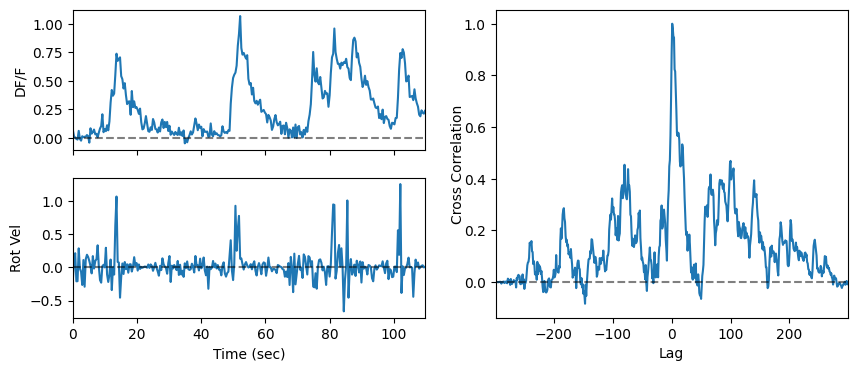

In [21]:
mosaic = [['img', 'corr'],
          ['bhv', 'corr']]
plots = ['img', 'bhv', 'corr']
fig, axd = plt.subplot_mosaic(mosaic, figsize=(10, 4))

# Plot DF/F and Rot Vel
for i in range(get_num_rois(expDf)):
    axd['img'].plot(expDf['posTime'], expDf[f'roi{i}'])
axd['bhv'].plot(expDf['posTime'], expDf['vRfilt'])

# Cross correlation
a = expDf['roi0']
v = expDf['vRfilt']
lags = range(-1*len(a)+1, len(a)-1+1)
cross_correlation = correlate_with_lag(a, v, lags)
axd['corr'].plot(lags, cross_correlation)

# Plot horizonal line at y=0
for plot in plots:
    axd[plot].axhline(y=0, color='black', linestyle='--', zorder=2, alpha=0.5)

# Set xlim
for plot in ['img', 'bhv']:
    axd[plot].set_xlim([round(expDf.iloc[0]['posTime']), expDf.iloc[-1]['posTime']])
axd['corr'].set_xlim([lags[0], lags[-1]])

# axd['corr'].set_xticklabels([ frame * expDf['posTime'].diff().mean() for frame in axd['corr'].get_xticks()])


axd['img'].set_xticklabels([])

axd['img'].set_ylabel("DF/F")
axd['bhv'].set_ylabel("Rot Vel")
axd['bhv'].set_xlabel("Time (sec)")
axd['corr'].set_ylabel("Cross Correlation", labelpad=-1)
axd['corr'].set_xlabel("Lag")

# Print peak correlation
peak_corr_lag = lags[np.argmax(cross_correlation)]
print(f'Peak correlation at {peak_corr_lag:+} frames of lag ({peak_corr_lag * fm_interval:+} seconds)')